# **Import Libraries**

In [1]:
!pip install fairlearn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference
from fairlearn.reductions import ExponentiatedGradient, DemographicParity

# **Load Dataset into DataFrame "German_Credit"**

In [3]:
German_Credit = pd.read_csv("german_credit_data.csv")

# **Explore Dataset**

In [4]:
German_Credit.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [5]:
German_Credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


In [6]:
German_Credit.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


# **Drop unnecessary columns**

In [7]:
German_Credit.drop(columns=['Unnamed: 0'], inplace=True)  # Drop index column

# **Check number of missing values per column**

In [8]:
# Check number of missing values per column
print("Missing values per column:")
print(German_Credit.isnull().sum())

Missing values per column:
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64


# **Handle missing values**

In [9]:
imputer_saving = SimpleImputer(strategy='most_frequent')
German_Credit['Saving accounts'] = imputer_saving.fit_transform(German_Credit[['Saving accounts']]).ravel()

imputer_checking = SimpleImputer(strategy='most_frequent')
German_Credit['Checking account'] = imputer_checking.fit_transform(German_Credit[['Checking account']]).ravel()

# **Age Distribution**

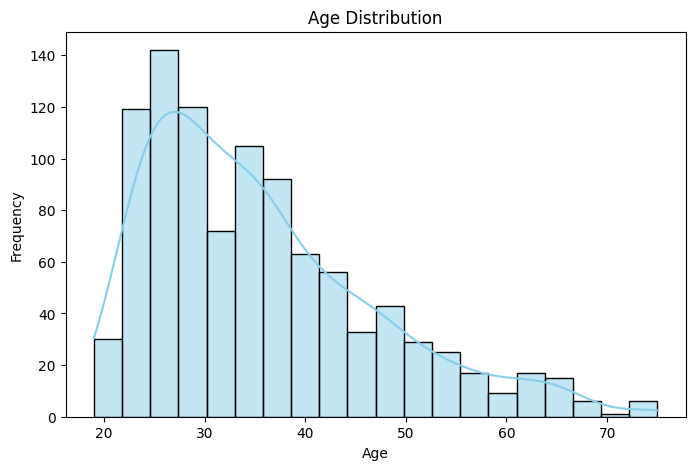

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(German_Credit['Age'], bins=20, kde=True, color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# **Credit Amount Distribution**

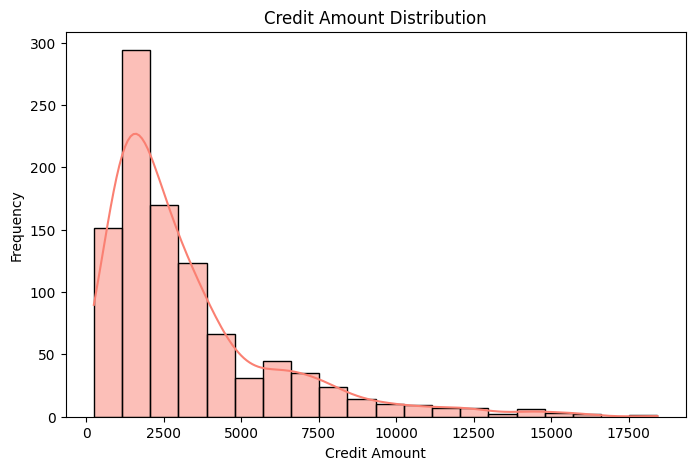

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(German_Credit['Credit amount'], bins=20, kde=True, color='salmon')
plt.title('Credit Amount Distribution')
plt.xlabel('Credit Amount')
plt.ylabel('Frequency')
plt.show()

# **Credit Amount vs Duration Scatter**

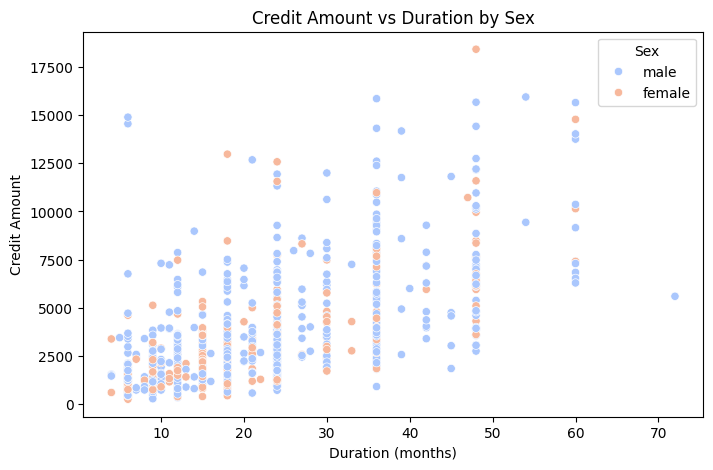

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Duration', y='Credit amount', hue='Sex', data=German_Credit, palette='coolwarm')
plt.title('Credit Amount vs Duration by Sex')
plt.xlabel('Duration (months)')
plt.ylabel('Credit Amount')
plt.show()

# **Count of Housing**

/tmp/ipykernel_25550/3980814745.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Housing', data=German_Credit, palette='Set3')


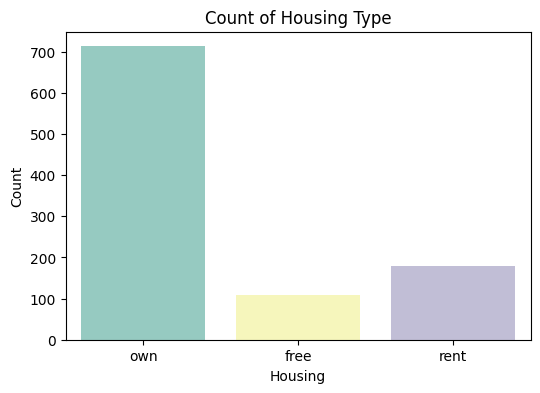

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='Housing', data=German_Credit, palette='Set3')
plt.title('Count of Housing Type')
plt.xlabel('Housing')
plt.ylabel('Count')
plt.show()

# **Count of Sex**

/tmp/ipykernel_25550/2544676455.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=German_Credit, palette='Set2')


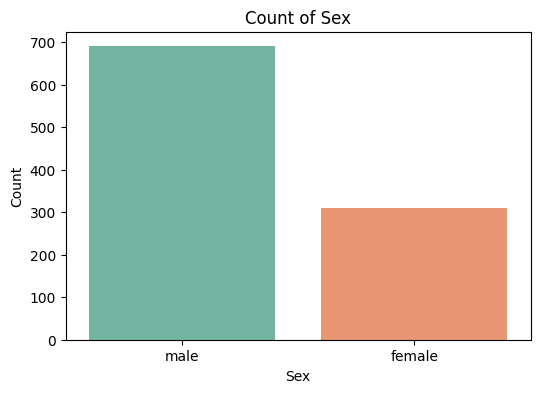

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', data=German_Credit, palette='Set2')
plt.title('Count of Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

# **Encode categorical variables**

In [15]:
categorical_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
for col in categorical_cols:
    German_Credit[col] = LabelEncoder().fit_transform(German_Credit[col])

# **Define features and target**

In [16]:
German_Credit['Target'] = (German_Credit['Credit amount'] > German_Credit['Credit amount'].median()).astype(int)
X = German_Credit.drop(columns=['Target', 'Credit amount'])
y = German_Credit['Target']

# **Split into train/test sets**

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


# **Train a baseline classifier**

In [18]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [19]:
y_pred = clf.predict(X_test)

# **Evaluate baseline model**

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7433333333333333
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.76      0.75       150
           1       0.75      0.73      0.74       150

    accuracy                           0.74       300
   macro avg       0.74      0.74      0.74       300
weighted avg       0.74      0.74      0.74       300



# **Fairness Evaluation using 'Sex' as sensitive feature**

In [21]:
sensitive_feature = X_test['Sex']
metric_frame = MetricFrame(
    metrics={'accuracy': accuracy_score},
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_feature
)

In [22]:
print("Accuracy by Sex:\n", metric_frame.by_group)
dp_diff = demographic_parity_difference(y_test, y_pred, sensitive_features=sensitive_feature)
eo_diff = equalized_odds_difference(y_test, y_pred, sensitive_features=sensitive_feature)
print("Demographic Parity Difference:", dp_diff)
print("Equalized Odds Difference:", eo_diff)

Accuracy by Sex:
      accuracy
Sex          
0    0.742268
1    0.743842
Demographic Parity Difference: 0.05916408511502724
Equalized Odds Difference: 0.04473244147157196


# **Bias Mitigation using Fairlearn**

In [23]:
mitigator = ExponentiatedGradient(
    estimator=RandomForestClassifier(n_estimators=100, random_state=42),
    constraints=DemographicParity()
)
mitigator.fit(X_train, y_train, sensitive_features=X_train['Sex'])


ExponentiatedGradient(constraints=<fairlearn.reductions._moments.utility_parity.DemographicParity object at 0x7cfe85057830>,
                      estimator=RandomForestClassifier(random_state=42),
                      nu=np.float64(0.0014255025282953427))

In [24]:
y_pred_mitigated = mitigator.predict(X_test)

# **Evaluate Mitigated Model**

In [25]:
print("Accuracy after mitigation:", accuracy_score(y_test, y_pred_mitigated))
metric_frame_mitigated = MetricFrame(
    metrics={'accuracy': accuracy_score},
    y_true=y_test,
    y_pred=y_pred_mitigated,
    sensitive_features=sensitive_feature
)

Accuracy after mitigation: 0.7133333333333334


In [26]:
print("Accuracy by Sex after mitigation:\n", metric_frame_mitigated.by_group)
dp_diff_mitigated = demographic_parity_difference(y_test, y_pred_mitigated, sensitive_features=sensitive_feature)
eo_diff_mitigated = equalized_odds_difference(y_test, y_pred_mitigated, sensitive_features=sensitive_feature)
print("Demographic Parity Difference after mitigation:", dp_diff_mitigated)
print("Equalized Odds Difference after mitigation:", eo_diff_mitigated)

Accuracy by Sex after mitigation:
      accuracy
Sex          
0    0.639175
1    0.748768
Demographic Parity Difference after mitigation: 0.020212279721700255
Equalized Odds Difference after mitigation: 0.13844325609031494


# **Visualize Model Performance Comparison**

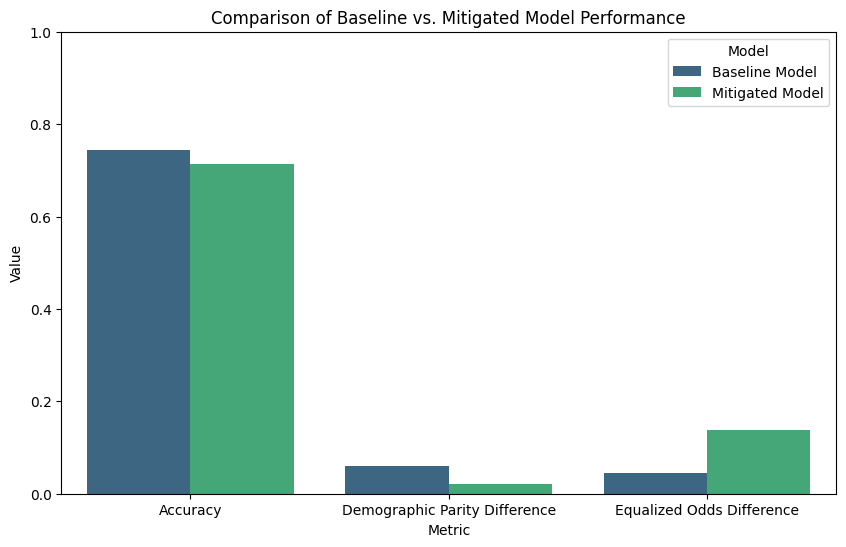

In [27]:
metrics_data = {
    'Metric': ['Accuracy', 'Demographic Parity Difference', 'Equalized Odds Difference'],
    'Baseline Model': [accuracy_score(y_test, y_pred), dp_diff, eo_diff],
    'Mitigated Model': [accuracy_score(y_test, y_pred_mitigated), dp_diff_mitigated, eo_diff_mitigated]
}
metrics_df = pd.DataFrame(metrics_data)

metrics_df_melted = metrics_df.melt(id_vars='Metric', var_name='Model', value_name='Value')

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Value', hue='Model', data=metrics_df_melted, palette='viridis')
plt.title('Comparison of Baseline vs. Mitigated Model Performance')
plt.ylabel('Value')
plt.ylim(0, 1) # Metrics are typically between 0 and 1
plt.show()